ECGR 5106 Homework 6

Student Name: Omar Mina-Blanco

Student ID: 800863713

In [ ]:
%pip -q install "transformers>=4.48,<6"

In [ ]:
import os
import gc
import math
import time
import random
import re
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet18, swin_t

from transformers import AutoImageProcessor, SwinForImageClassification
from IPython.display import display

try:
    from torch.utils.flop_counter import FlopCounterMode
except ImportError as exc:
    raise RuntimeError(
        "torch.utils.flop_counter.FlopCounterMode."
    ) from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA:", torch.version.cuda)
else:
    print("running CPU")

DATA_DIR = Path("/content/data")
OUTPUT_DIR = Path("/content/vit_cifar100_outputs")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)
print("Checkpoint directory:", CHECKPOINT_DIR)

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
CUDA: 12.8
Output directory: /content/vit_cifar100_outputs
Checkpoint directory: /content/vit_cifar100_outputs/checkpoints


In [ ]:
def synchronize_device(): #accurate gpu timing
    if device.type == "cuda":
        torch.cuda.synchronize()

def count_parameters(model): #count trainable parameter counts
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
    return total, trainable

def calculate_model_size(model):#size in MiB.
    parameter_bytes = sum(
        parameter.numel() * parameter.element_size()
        for parameter in model.parameters()
    )
    buffer_bytes = sum(
        buffer.numel() * buffer.element_size()
        for buffer in model.buffers()
    )
    return (parameter_bytes + buffer_bytes) / (1024 ** 2)


@torch.no_grad()
def calculate_forward_flops(model, input_shape): #count Flops
    was_training = model.training
    model.eval()

    model_device = next(model.parameters()).device
    dummy_input = torch.randn(1, *input_shape, device=model_device)

    counter = FlopCounterMode(display=False)
    with counter:
        _ = model(dummy_input)

    total_flops = int(counter.get_total_flops())

    if was_training:
        model.train()

    return total_flops


def amp_context():
    if device.type == "cuda":
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


def make_grad_scaler(): #create gradient scaler
    enabled = device.type == "cuda"

    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def make_safe_filename(name): #filename for saving
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name)


def build_learning_rate_scheduler(
    optimizer,
    epochs,
    base_learning_rate,
    warmup_epochs=0,
    minimum_lr_ratio=0.01,
):

    minimum_lr = base_learning_rate * minimum_lr_ratio
#1 epoch warmup
    if warmup_epochs > 0 and epochs > warmup_epochs:
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer,
            start_factor=0.1,
            end_factor=1.0,
            total_iters=warmup_epochs,
        )
#cosine annealing reduces lr
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, epochs - warmup_epochs),
            eta_min=minimum_lr,
        )

        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, cosine_scheduler],
            milestones=[warmup_epochs],
        )

        scheduler_description = (
            f"Linear warmup ({warmup_epochs} epoch) + cosine annealing"
        )
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=max(1, epochs),
            eta_min=minimum_lr,
        )
        scheduler_description = "Cosine annealing"

    return scheduler, scheduler_description


@torch.no_grad()
def evaluate_classifier(model, loader, criterion): #cross entropy loss

    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with amp_context():
            logits = model(images)
            loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size

    return (
        total_loss / max(1, total_examples),
        total_correct / max(1, total_examples),
    )


def train_classifier( #regularization
    model,
    train_loader,
    val_loader,
    epochs,
    learning_rate,
    experiment_name,
    weight_decay=1e-4,
    gradient_clip_norm=1.0,
    label_smoothing=0.0,
    warmup_epochs=0,
    early_stopping_patience=None,
    minimum_epochs_before_stopping=1,
):

    model = model.to(device)

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if parameter.requires_grad
    ]

    if not trainable_parameters:
        raise ValueError("No trainable parameters")

    # weight decay for L2 regularization
    optimizer = torch.optim.Adam(
        trainable_parameters,
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler, scheduler_description = build_learning_rate_scheduler(
        optimizer=optimizer,
        epochs=epochs,
        base_learning_rate=learning_rate,
        warmup_epochs=warmup_epochs,
    )

    # Label smoothing
    criterion = nn.CrossEntropyLoss(
        label_smoothing=label_smoothing,
    )

    scaler = make_grad_scaler()

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "epoch_time_s": [],
        "learning_rate": [],
    }

    best_state = None
    best_epoch = 0
    best_train_loss = math.inf
    best_val_loss = math.inf
    best_val_accuracy = -math.inf
    epochs_without_improvement = 0
    stopped_early = False

    synchronize_device()
    total_start = time.perf_counter()

    for epoch in range(epochs):
        model.train()

        #evaluation mode.
        if hasattr(model, "set_eval"):
            model.set_eval()

        running_loss = 0.0
        running_correct = 0
        running_examples = 0

        current_learning_rate = optimizer.param_groups[0]["lr"]
        history["learning_rate"].append(current_learning_rate)

        synchronize_device()
        epoch_start = time.perf_counter()

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with amp_context():
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()

            # Unscale for gradient norm
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                trainable_parameters,
                max_norm=gradient_clip_norm,
            )

            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            running_examples += batch_size

        synchronize_device()
        epoch_time = time.perf_counter() - epoch_start

        train_loss = running_loss / max(1, running_examples)
        train_accuracy = running_correct / max(1, running_examples)
        val_loss, val_accuracy = evaluate_classifier(
            model,
            val_loader,
            criterion,
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["epoch_time_s"].append(epoch_time)

        accuracy_improved = val_accuracy > best_val_accuracy + 1e-12
        loss_breaks_tie = ( #if tie, choose lower validation loss
            abs(val_accuracy - best_val_accuracy) <= 1e-12
            and val_loss < best_val_loss
        )
        improved = accuracy_improved or loss_breaks_tie

        if improved:
            best_epoch = epoch + 1
            best_train_loss = train_loss
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            epochs_without_improvement = 0

            # Move the best state to CPU
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            epochs_without_improvement += 1

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"lr {current_learning_rate:.3e} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_accuracy:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_accuracy:.4f} | "
            f"time {epoch_time:.2f} s"
            + (" | BEST" if improved else "")
        )

        scheduler.step()

        if (
            early_stopping_patience is not None
            and epoch + 1 >= minimum_epochs_before_stopping
            and epochs_without_improvement >= early_stopping_patience
        ):
            print(
                "Early stopping: validation accuracy did not improve for "
                f"{early_stopping_patience} consecutive epochs."
            )
            stopped_early = True
            break

    synchronize_device()
    total_training_time = time.perf_counter() - total_start

    if best_state is None:
        raise RuntimeError("no best state")

    # use best state
    model.load_state_dict(best_state)

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{make_safe_filename(experiment_name)}_best.pt"
    )

    torch.save(
        {
            "experiment_name": experiment_name,
            "best_epoch": best_epoch,
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,
            "best_val_accuracy": best_val_accuracy,
            "model_state_dict": best_state,
        },
        checkpoint_path,
    )

    training_summary = {
        "epochs_requested": epochs,
        "epochs_trained": len(history["train_loss"]),
        "best_epoch": best_epoch,
        "best_train_loss": best_train_loss,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "last_epoch_train_loss": history["train_loss"][-1],
        "last_epoch_val_loss": history["val_loss"][-1],
        "last_epoch_val_accuracy": history["val_accuracy"][-1],
        "total_training_time_s": total_training_time,
        "mean_training_time_per_epoch_s": float(
            np.mean(history["epoch_time_s"])
        ),
        "weight_decay": weight_decay,
        "gradient_clip_norm": gradient_clip_norm,
        "label_smoothing": label_smoothing,
        "scheduler": scheduler_description,
        "warmup_epochs": warmup_epochs,
        "early_stopping_patience": early_stopping_patience,
        "stopped_early": stopped_early,
        "checkpoint_path": str(checkpoint_path),
    }

    print(
        f"Restored best from epoch {best_epoch}: "
        f"val acc {best_val_accuracy:.4f}, "
        f"val loss {best_val_loss:.4f}"
    )
    print("Saved best", checkpoint_path)

    return model, history, training_summary


def plot_training_history(history, title, best_epoch=None):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], marker="o", label="Training loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
    if best_epoch is not None:
        plt.axvline(
            best_epoch,
            linestyle="--",
            label=f"Best epoch = {best_epoch}",
        )
    plt.xlabel("Epoch")
    plt.ylabel("Cross-entropy loss")
    plt.title(f"{title}: Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(
        epochs,
        np.array(history["train_accuracy"]) * 100,
        marker="o",
        label="Training accuracy",
    )
    plt.plot(
        epochs,
        np.array(history["val_accuracy"]) * 100,
        marker="o",
        label="Validation accuracy",
    )
    if best_epoch is not None:
        plt.axvline(
            best_epoch,
            linestyle="--",
            label=f"Best epoch = {best_epoch}",
        )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title}: Accuracy")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["epoch_time_s"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Training time (s)")
    plt.title(f"{title}: Training Time per Epoch")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["learning_rate"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title(f"{title}: Learning-Rate Schedule")
    plt.grid(True, alpha=0.3)
    plt.show()


def save_results_table(dataframe, filename):
    """Save a results table as CSV and HTML."""
    csv_path = OUTPUT_DIR / f"{filename}.csv"
    html_path = OUTPUT_DIR / f"{filename}.html"

    dataframe.to_csv(csv_path, index=False)
    dataframe.to_html(html_path, index=False)

    print("Saved:", csv_path)
    print("Saved:", html_path)

# Problem 1 — Vision Transformer from Scratch vs. ResNet-18



In [ ]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408) #CIFAR-100 channel means and std deviations from the RGB pixel distributions of the CIFAR-100 training images
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

NUM_CLASSES = 100
P1_BATCH_SIZE = 64
P1_EPOCHS = 10
P1_LEARNING_RATE = 1e-3
P1_VALIDATION_SIZE = 5000

# Regularization/stability settings for all Problem 1 models.
P1_WEIGHT_DECAY = 1e-4
P1_GRADIENT_CLIP_NORM = 1.0
P1_LABEL_SMOOTHING = 0.1
P1_WARMUP_EPOCHS = 1

P1_EARLY_STOPPING_PATIENCE = None #set to 1,2,3 for early stopping

p1_train_transform = transforms.Compose([
    # random crop and horizontal flip
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

p1_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

# Separate train and validation dataset
p1_full_train_aug = datasets.CIFAR100(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=p1_train_transform,
)

p1_full_train_eval = datasets.CIFAR100(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=p1_eval_transform,
)

p1_test_dataset = datasets.CIFAR100(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=p1_eval_transform,
)

# Fixed indices
split_generator = torch.Generator().manual_seed(SEED)
all_indices = torch.randperm(
    len(p1_full_train_aug),
    generator=split_generator,
).tolist()

val_indices = all_indices[:P1_VALIDATION_SIZE]
train_indices = all_indices[P1_VALIDATION_SIZE:]

p1_train_dataset = Subset(p1_full_train_aug, train_indices)
p1_val_dataset = Subset(p1_full_train_eval, val_indices)

loader_kwargs = {
    "num_workers": 2,
    "pin_memory": (device.type == "cuda"),
    "persistent_workers": True,
}

p1_train_loader = DataLoader(
    p1_train_dataset,
    batch_size=P1_BATCH_SIZE,
    shuffle=True,
    **loader_kwargs,
)

p1_val_loader = DataLoader(
    p1_val_dataset,
    batch_size=P1_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

p1_test_loader = DataLoader(
    p1_test_dataset,
    batch_size=P1_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

print("Train:", len(p1_train_dataset))
print("Validation:", len(p1_val_dataset))
print("Test:", len(p1_test_dataset))
print("Classes:", len(p1_test_dataset.classes))
print("Problem 1 weight decay:", P1_WEIGHT_DECAY)
print("Problem 1 label smoothing:", P1_LABEL_SMOOTHING)
print("Problem 1 gradient clip norm:", P1_GRADIENT_CLIP_NORM)

100%|██████████| 169M/169M [1:07:58<00:00, 41.4kB/s]


Train: 45000
Validation: 5000
Test: 10000
Classes: 100
Problem 1 weight decay: 0.0001
Problem 1 label smoothing: 0.1
Problem 1 gradient clip norm: 1.0


In [ ]:
class MultiHeadSelfAttention(nn.Module):

    def __init__(self, d_model, num_heads, attention_dropout=0.1, projection_dropout=0.1):
        super().__init__()

        if d_model % num_heads != 0:
            raise ValueError("must be divisible by num_heads")

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5

        # queries, keys, and values
        self.qkv = nn.Linear(d_model, 3 * d_model)

        self.attention_dropout = nn.Dropout(attention_dropout)
        self.projection = nn.Linear(d_model, d_model)
        self.projection_dropout = nn.Dropout(projection_dropout)

    def forward(self, x):
        batch_size, token_count, d_model = x.shape

        # [B, N, 3D] to [3, B, H, N, D/H]
        qkv = self.qkv(x)
        qkv = qkv.reshape(
            batch_size,
            token_count,
            3,
            self.num_heads,
            self.head_dim,
        ).permute(2, 0, 3, 1, 4)

        queries, keys, values = qkv[0], qkv[1], qkv[2]

        #every image token
        attention_scores = (
            queries @ keys.transpose(-2, -1)
        ) * self.scale

        attention_weights = torch.softmax(
            attention_scores,
            dim=-1,
        )
        attention_weights = self.attention_dropout(attention_weights)

        # weighted sum of vectors.
        attended = attention_weights @ values
        attended = attended.transpose(1, 2).reshape(
            batch_size,
            token_count,
            d_model,
        )

        output = self.projection(attended)
        return self.projection_dropout(output)

#2 layer MLP with droptout and GELU
class TransformerMLP(nn.Module):

    def __init__(self, d_model, mlp_dim, dropout=0.1):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(d_model, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.network(x)


class VisionTransformerBlock(nn.Module):

    def __init__(self, d_model, num_heads, mlp_dim, dropout=0.1):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)
        self.attention = MultiHeadSelfAttention(
            d_model=d_model,
            num_heads=num_heads,
            attention_dropout=dropout,
            projection_dropout=dropout,
        )

        self.norm2 = nn.LayerNorm(d_model)
        self.mlp = TransformerMLP(
            d_model=d_model,
            mlp_dim=mlp_dim,
            dropout=dropout,
        )

    def forward(self, x):
        # Residual connections
        x = x + self.attention(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


class VisionTransformerScratch(nn.Module): #vision transformer for 32x32

    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=100,
        d_model=256,
        num_layers=4,
        num_heads=4,
        mlp_dim=1024,
        dropout=0.1,
    ):
        super().__init__()

        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size.")

        if d_model % num_heads != 0:
            raise ValueError("d_model must be divisible by num_heads.")

        patches_per_side = image_size // patch_size
        self.num_patches = patches_per_side ** 2

        self.patch_embedding = nn.Conv2d(
            in_channels,
            d_model,
            kernel_size=patch_size,
            stride=patch_size,
        )

        #global classification token
        self.class_token = nn.Parameter(torch.zeros(1, 1, d_model))

        #position vector for each patch plus the class token
        self.position_embedding = nn.Parameter(
            torch.zeros(1, self.num_patches + 1, d_model)
        )

        self.embedding_dropout = nn.Dropout(dropout)

        self.encoder_blocks = nn.ModuleList([
            VisionTransformerBlock(
                d_model=d_model,
                num_heads=num_heads,
                mlp_dim=mlp_dim,
                dropout=dropout,
            )
            for _ in range(num_layers)
        ])

        self.final_norm = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(d_model, num_classes)

        self._initialize_weights()

    def _initialize_weights(self):
        #Initialize tokens, positions, linear layers
        nn.init.trunc_normal_(self.class_token, std=0.02)
        nn.init.trunc_normal_(self.position_embedding, std=0.02)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.trunc_normal_(module.weight, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.LayerNorm):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, images):
        # [B, 3, 32, 32] to [B, D, H/P, W/P]
        tokens = self.patch_embedding(images)

        # [B, D, H/P, W/P] to [B, N, D]
        tokens = tokens.flatten(2).transpose(1, 2)

        class_tokens = self.class_token.expand(tokens.size(0), -1, -1)
        tokens = torch.cat((class_tokens, tokens), dim=1)

        tokens = tokens + self.position_embedding
        tokens = self.embedding_dropout(tokens)

        for encoder_block in self.encoder_blocks:
            tokens = encoder_block(tokens)

        class_representation = self.final_norm(tokens[:, 0])
        return self.classifier(class_representation)


def theoretical_vit_parameter_count(
    image_size,
    patch_size,
    d_model,
    num_layers,
    num_classes=100,
    in_channels=3,
):
    num_patches = (image_size // patch_size) ** 2

    patch_embedding = in_channels * patch_size**2 * d_model + d_model
    class_token = d_model
    position_embedding = (num_patches + 1) * d_model

    # Attention= 4D^2 + 4D
    # MLP 4D = 8D^2 + 5D
    # Two LayerNorms= 4D
    parameters_per_block = 12 * d_model**2 + 13 * d_model

    final_norm = 2 * d_model
    classifier = num_classes * d_model + num_classes

    return int(
        patch_embedding
        + class_token
        + position_embedding
        + num_layers * parameters_per_block
        + final_norm
        + classifier
    )

In [2]:
VIT_CONFIGS = [ #4 configurations for problem 1
    {
        "name": "ViT_P4_D256_L4_H4",
        "patch_size": 4,
        "d_model": 256,
        "num_layers": 4,
        "num_heads": 4,
    },
    {
        "name": "ViT_P4_D256_L8_H8",
        "patch_size": 4,
        "d_model": 256,
        "num_layers": 8,
        "num_heads": 8,
    },
    {
        "name": "ViT_P8_D512_L4_H8",
        "patch_size": 8,
        "d_model": 512,
        "num_layers": 4,
        "num_heads": 8,
    },
    {
        "name": "ViT_P8_D512_L8_H8",
        "patch_size": 8,
        "d_model": 512,
        "num_layers": 8,
        "num_heads": 8,
    },
]

display(pd.DataFrame(VIT_CONFIGS))

NameError: name 'pd' is not defined

In [ ]:
parameter_checks = []

for config in VIT_CONFIGS:
    model = VisionTransformerScratch(
        patch_size=config["patch_size"],
        d_model=config["d_model"],
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        mlp_dim=4 * config["d_model"],
    ).to(device)

    actual_params, _ = count_parameters(model)

    theoretical_params = theoretical_vit_parameter_count(
        image_size=32,
        patch_size=config["patch_size"],
        d_model=config["d_model"],
        num_layers=config["num_layers"],
    )

    profiled_flops = calculate_forward_flops(
        model,
        input_shape=(3, 32, 32),
    )

    parameter_checks.append({
        "model": config["name"],
        "theoretical_params": theoretical_params,
        "actual_params": actual_params,
        "difference": actual_params - theoretical_params,
        "automatic_forward_flops": profiled_flops,
    })

    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

parameter_check_df = pd.DataFrame(parameter_checks)
display(parameter_check_df)

assert (parameter_check_df["difference"] == 0).all()
assert (parameter_check_df["automatic_forward_flops"] > 0).all()

,model,theoretical_params,actual_params,difference,automatic_forward_flops
0,ViT_P4_D256_L4_H4,3214692,3214692,0,427874304
1,ViT_P4_D256_L8_H8,6373732,6373732,0,854124544
2,ViT_P8_D512_L4_H8,12769892,12769892,0,433434624
3,ViT_P8_D512_L8_H8,25379428,25379428,0,863621120



Training: ViT_P4_D256_L4_H4
Epoch 01/10 | lr 1.000e-04 | train loss 4.1506 | train acc 0.0811 | val loss 3.9088 | val acc 0.1264 | time 13.20 s | BEST
Epoch 02/10 | lr 1.000e-03 | train loss 3.9943 | train acc 0.1025 | val loss 3.7659 | val acc 0.1446 | time 11.48 s | BEST
Epoch 03/10 | lr 9.701e-04 | train loss 3.6958 | train acc 0.1630 | val loss 3.5569 | val acc 0.2052 | time 12.58 s | BEST
Epoch 04/10 | lr 8.842e-04 | train loss 3.5496 | train acc 0.1953 | val loss 3.4365 | val acc 0.2258 | time 11.59 s | BEST
Epoch 05/10 | lr 7.525e-04 | train loss 3.4358 | train acc 0.2217 | val loss 3.3397 | val acc 0.2466 | time 11.49 s | BEST
Epoch 06/10 | lr 5.910e-04 | train loss 3.3342 | train acc 0.2486 | val loss 3.2736 | val acc 0.2714 | time 11.36 s | BEST
Epoch 07/10 | lr 4.190e-04 | train loss 3.2424 | train acc 0.2689 | val loss 3.1604 | val acc 0.2964 | time 12.06 s | BEST
Epoch 08/10 | lr 2.575e-04 | train loss 3.1530 | train acc 0.2900 | val loss 3.0930 | val acc 0.3136 | time 11

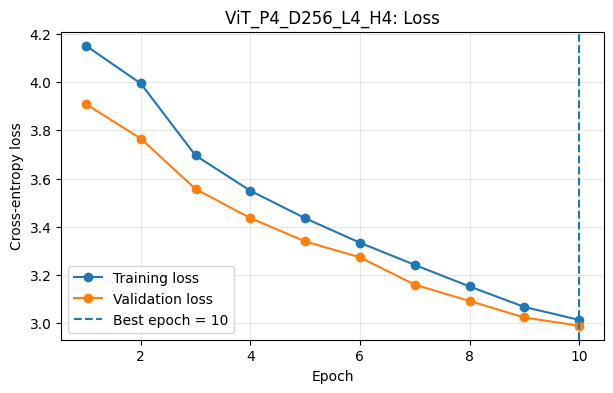

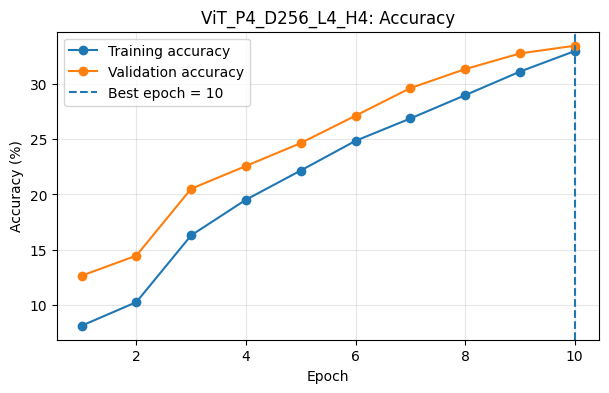

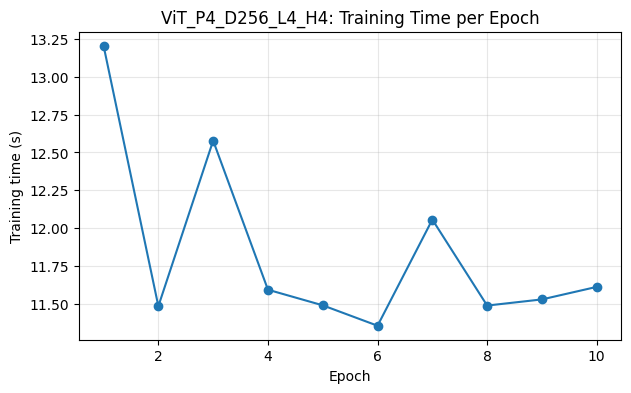

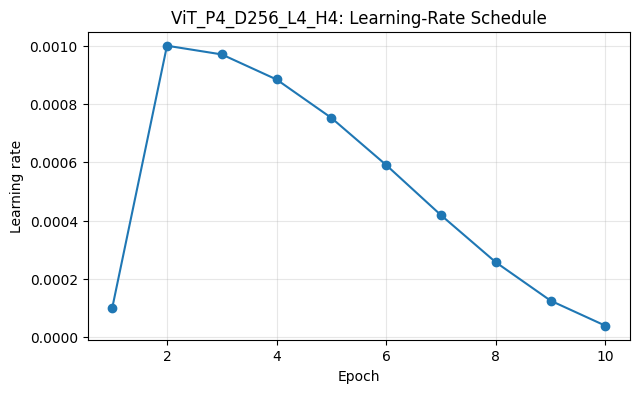


Training: ViT_P4_D256_L8_H8
Epoch 01/10 | lr 1.000e-04 | train loss 4.1377 | train acc 0.0838 | val loss 3.9016 | val acc 0.1178 | time 21.64 s | BEST
Epoch 02/10 | lr 1.000e-03 | train loss 3.9964 | train acc 0.1038 | val loss 3.7861 | val acc 0.1456 | time 22.01 s | BEST
Epoch 03/10 | lr 9.701e-04 | train loss 3.6961 | train acc 0.1628 | val loss 3.5691 | val acc 0.1930 | time 20.77 s | BEST
Epoch 04/10 | lr 8.842e-04 | train loss 3.5124 | train acc 0.2041 | val loss 3.3749 | val acc 0.2364 | time 21.06 s | BEST
Epoch 05/10 | lr 7.525e-04 | train loss 3.3748 | train acc 0.2372 | val loss 3.2601 | val acc 0.2690 | time 21.43 s | BEST
Epoch 06/10 | lr 5.910e-04 | train loss 3.2526 | train acc 0.2663 | val loss 3.1530 | val acc 0.3016 | time 22.84 s | BEST
Epoch 07/10 | lr 4.190e-04 | train loss 3.1482 | train acc 0.2914 | val loss 3.0750 | val acc 0.3134 | time 21.49 s | BEST
Epoch 08/10 | lr 2.575e-04 | train loss 3.0407 | train acc 0.3209 | val loss 2.9770 | val acc 0.3414 | time 20

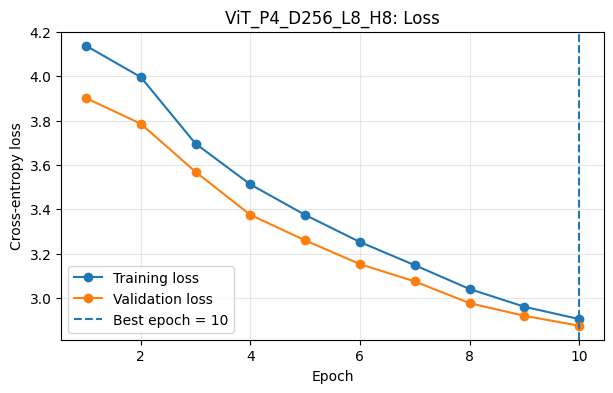

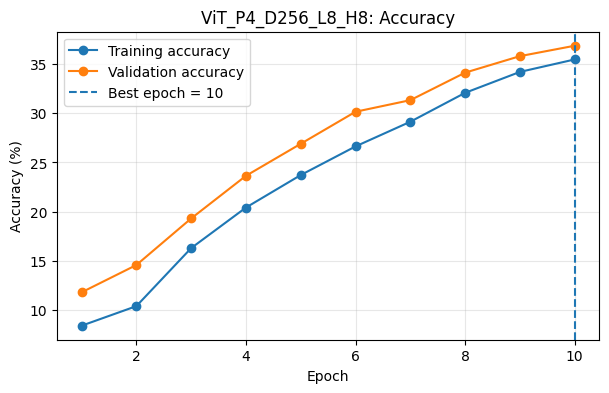

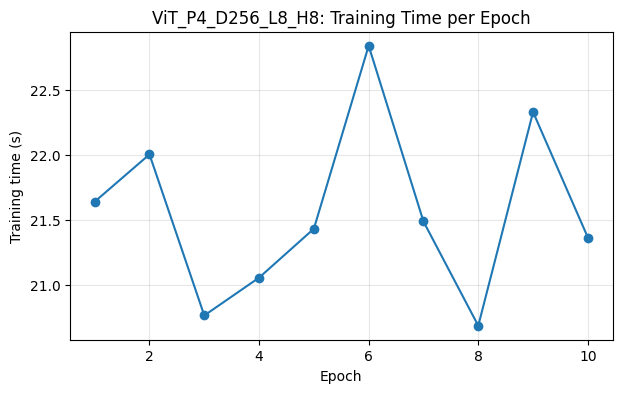

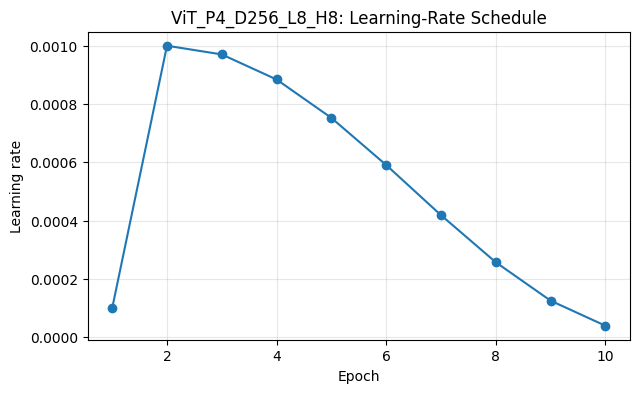


Training: ViT_P8_D512_L4_H8
Epoch 01/10 | lr 1.000e-04 | train loss 4.0832 | train acc 0.0949 | val loss 3.9344 | val acc 0.1234 | time 11.70 s | BEST
Epoch 02/10 | lr 1.000e-03 | train loss 4.2005 | train acc 0.0734 | val loss 4.0667 | val acc 0.0912 | time 11.59 s
Epoch 03/10 | lr 9.701e-04 | train loss 4.0240 | train acc 0.0998 | val loss 3.9459 | val acc 0.1136 | time 11.71 s
Epoch 04/10 | lr 8.842e-04 | train loss 3.8919 | train acc 0.1249 | val loss 3.8634 | val acc 0.1266 | time 11.97 s | BEST
Epoch 05/10 | lr 7.525e-04 | train loss 3.7875 | train acc 0.1492 | val loss 3.7970 | val acc 0.1518 | time 11.47 s | BEST
Epoch 06/10 | lr 5.910e-04 | train loss 3.6807 | train acc 0.1691 | val loss 3.6502 | val acc 0.1744 | time 11.93 s | BEST
Epoch 07/10 | lr 4.190e-04 | train loss 3.5722 | train acc 0.1974 | val loss 3.5541 | val acc 0.1944 | time 11.78 s | BEST
Epoch 08/10 | lr 2.575e-04 | train loss 3.4758 | train acc 0.2182 | val loss 3.5048 | val acc 0.2160 | time 11.84 s | BEST
E

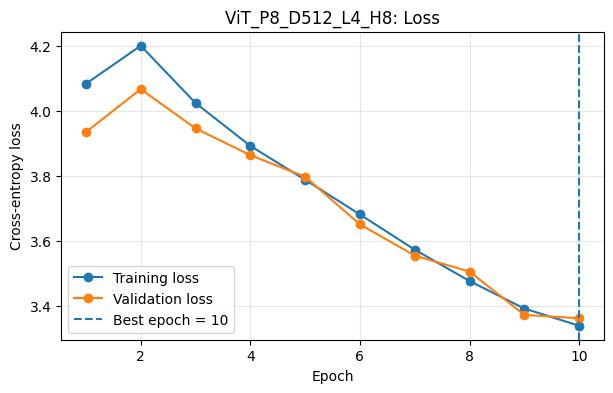

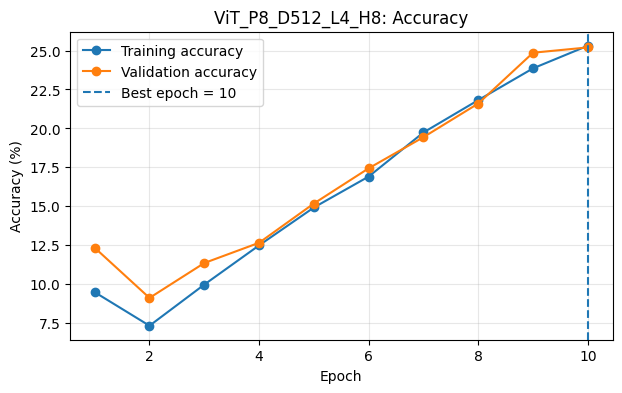

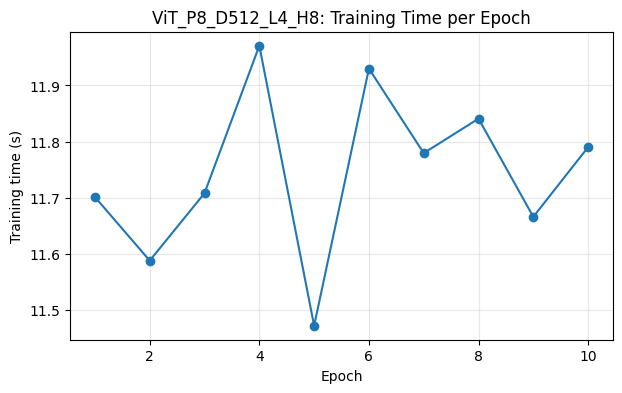

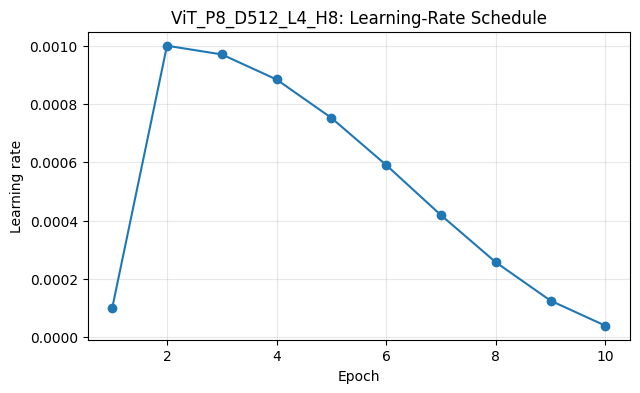


Training: ViT_P8_D512_L8_H8
Epoch 01/10 | lr 1.000e-04 | train loss 4.0893 | train acc 0.0892 | val loss 3.8779 | val acc 0.1300 | time 21.00 s | BEST
Epoch 02/10 | lr 1.000e-03 | train loss 4.2095 | train acc 0.0702 | val loss 4.0892 | val acc 0.0826 | time 21.11 s
Epoch 03/10 | lr 9.701e-04 | train loss 4.0260 | train acc 0.0998 | val loss 3.9401 | val acc 0.1152 | time 21.25 s
Epoch 04/10 | lr 8.842e-04 | train loss 3.8920 | train acc 0.1238 | val loss 3.8427 | val acc 0.1334 | time 22.79 s | BEST
Epoch 05/10 | lr 7.525e-04 | train loss 3.7732 | train acc 0.1488 | val loss 3.7251 | val acc 0.1584 | time 22.51 s | BEST
Epoch 06/10 | lr 5.910e-04 | train loss 3.6722 | train acc 0.1750 | val loss 3.6952 | val acc 0.1768 | time 20.94 s | BEST
Epoch 07/10 | lr 4.190e-04 | train loss 3.5682 | train acc 0.1979 | val loss 3.5392 | val acc 0.2018 | time 21.34 s | BEST
Epoch 08/10 | lr 2.575e-04 | train loss 3.4746 | train acc 0.2189 | val loss 3.4319 | val acc 0.2306 | time 21.14 s | BEST
E

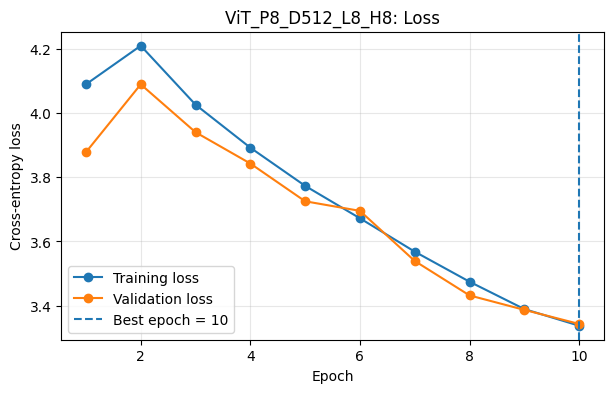

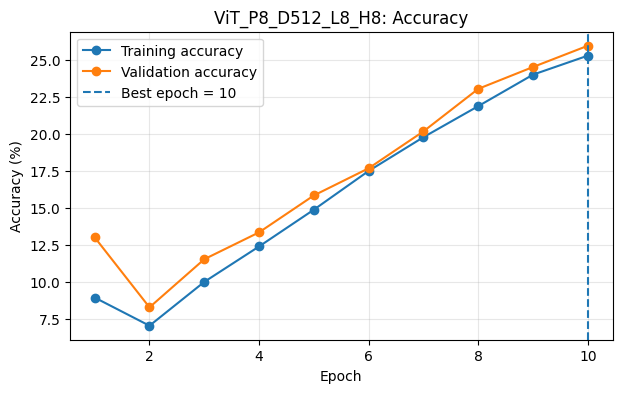

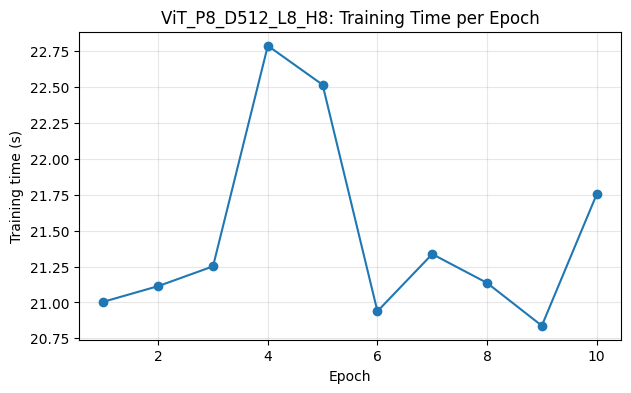

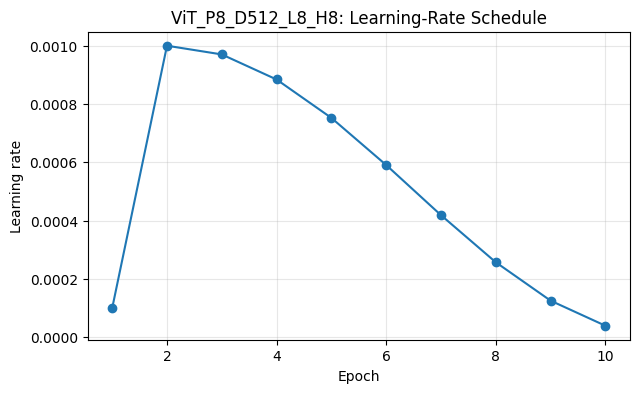

,model,model_family,patch_size,d_model,blocks,heads,mlp_dim,dropout,weight_decay,label_smoothing,...,model_size,flops_forward_batch1,total_training_time_s,mean_training_time_per_epoch_s,best_train_loss,best_val_loss,best_val_accuracy,test_loss_best_checkpoint,test_accuracy_best_checkpoint,checkpoint_path
0,ViT_P4_D256_L4_H4,Scratch ViT,4,256,4,4,1024,0.1,0.0001,0.1,...,12.263077,427874304,125.618053,11.838988,3.014339,2.990286,0.3348,2.996587,0.3325,/content/vit_cifar100_outputs/checkpoints/ViT_...
1,ViT_P4_D256_L8_H8,Scratch ViT,4,256,8,8,1024,0.1,0.0001,0.1,...,24.313858,854124544,223.475248,21.561270,2.905233,2.875132,0.3688,2.871412,0.3707,/content/vit_cifar100_outputs/checkpoints/ViT_...
2,ViT_P8_D512_L4_H8,Scratch ViT,8,512,4,8,2048,0.1,0.0001,0.1,...,48.713272,433434624,124.674946,11.744858,3.338007,3.360975,0.2520,3.378139,0.2449,/content/vit_cifar100_outputs/checkpoints/ViT_...
3,ViT_P8_D512_L8_H8,Scratch ViT,8,512,8,8,2048,0.1,0.0001,0.1,...,96.814835,863621120,222.382702,21.466995,3.337553,3.343067,0.2598,3.365679,0.2480,/content/vit_cifar100_outputs/checkpoints/ViT_...


Saved: /content/vit_cifar100_outputs/problem1_vit_results_regularized.csv
Saved: /content/vit_cifar100_outputs/problem1_vit_results_regularized.html


In [ ]:
p1_results = []
p1_histories = {}

for config in VIT_CONFIGS:
    print("\n" + "=" * 90)
    print("Training:", config["name"])
    print("=" * 90)

    model = VisionTransformerScratch(
        patch_size=config["patch_size"],
        d_model=config["d_model"],
        num_layers=config["num_layers"],
        num_heads=config["num_heads"],
        mlp_dim=4 * config["d_model"],
        dropout=0.1,
    ).to(device)

    theoretical_params = theoretical_vit_parameter_count(
        image_size=32,
        patch_size=config["patch_size"],
        d_model=config["d_model"],
        num_layers=config["num_layers"],
    )

    actual_params, trainable_params = count_parameters(model)
    model_size = calculate_model_size(model)
    forward_flops = calculate_forward_flops(model, (3, 32, 32))

    #best validation epoch
    model, history, training_summary = train_classifier(
        model=model,
        train_loader=p1_train_loader,
        val_loader=p1_val_loader,
        epochs=P1_EPOCHS,
        learning_rate=P1_LEARNING_RATE,
        experiment_name=config["name"],
        weight_decay=P1_WEIGHT_DECAY,
        gradient_clip_norm=P1_GRADIENT_CLIP_NORM,
        label_smoothing=P1_LABEL_SMOOTHING,
        warmup_epochs=P1_WARMUP_EPOCHS,
        early_stopping_patience=P1_EARLY_STOPPING_PATIENCE,
    )

    # Test data evaluated after model selection
    criterion = nn.CrossEntropyLoss(
        label_smoothing=P1_LABEL_SMOOTHING,
    )
    test_loss, test_accuracy = evaluate_classifier(
        model,
        p1_test_loader,
        criterion,
    )

    p1_histories[config["name"]] = history

    p1_results.append({
        "model": config["name"],
        "model_family": "Scratch ViT",
        "patch_size": config["patch_size"],
        "d_model": config["d_model"],
        "blocks": config["num_layers"],
        "heads": config["num_heads"],
        "mlp_dim": 4 * config["d_model"],
        "dropout": 0.1,
        "weight_decay": training_summary["weight_decay"],
        "label_smoothing": training_summary["label_smoothing"],
        "gradient_clip_norm": training_summary["gradient_clip_norm"],
        "scheduler": training_summary["scheduler"],
        "best_epoch": training_summary["best_epoch"],
        "epochs_trained": training_summary["epochs_trained"],
        "theoretical_params": theoretical_params,
        "actual_params": actual_params,
        "trainable_params": trainable_params,
        "model_size": model_size,
        "flops_forward_batch1": forward_flops,
        "total_training_time_s": training_summary["total_training_time_s"],
        "mean_training_time_per_epoch_s": training_summary[
            "mean_training_time_per_epoch_s"
        ],
        "best_train_loss": training_summary["best_train_loss"],
        "best_val_loss": training_summary["best_val_loss"],
        "best_val_accuracy": training_summary["best_val_accuracy"],
        "test_loss_best_checkpoint": test_loss,
        "test_accuracy_best_checkpoint": test_accuracy,
        "checkpoint_path": training_summary["checkpoint_path"],
    })

    plot_training_history(
        history,
        config["name"],
        best_epoch=training_summary["best_epoch"],
    )

    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

p1_vit_results_df = pd.DataFrame(p1_results)
display(p1_vit_results_df)
save_results_table(
    p1_vit_results_df,
    "problem1_vit_results_regularized",
)


Training: ResNet18_CIFAR100_Scratch
Epoch 01/10 | lr 1.000e-04 | train loss 3.8676 | train acc 0.1394 | val loss 3.4679 | val acc 0.2172 | time 10.35 s | BEST
Epoch 02/10 | lr 1.000e-03 | train loss 3.6481 | train acc 0.1782 | val loss 3.2843 | val acc 0.2460 | time 9.96 s | BEST
Epoch 03/10 | lr 9.701e-04 | train loss 3.0853 | train acc 0.3037 | val loss 2.8809 | val acc 0.3672 | time 9.76 s | BEST
Epoch 04/10 | lr 8.842e-04 | train loss 2.7635 | train acc 0.3859 | val loss 2.6748 | val acc 0.4240 | time 9.88 s | BEST
Epoch 05/10 | lr 7.525e-04 | train loss 2.5205 | train acc 0.4584 | val loss 2.5338 | val acc 0.4642 | time 9.77 s | BEST
Epoch 06/10 | lr 5.910e-04 | train loss 2.3102 | train acc 0.5187 | val loss 2.3014 | val acc 0.5252 | time 9.87 s | BEST
Epoch 07/10 | lr 4.190e-04 | train loss 2.1137 | train acc 0.5803 | val loss 2.1840 | val acc 0.5728 | time 9.87 s | BEST
Epoch 08/10 | lr 2.575e-04 | train loss 1.9242 | train acc 0.6388 | val loss 2.0191 | val acc 0.6072 | time 

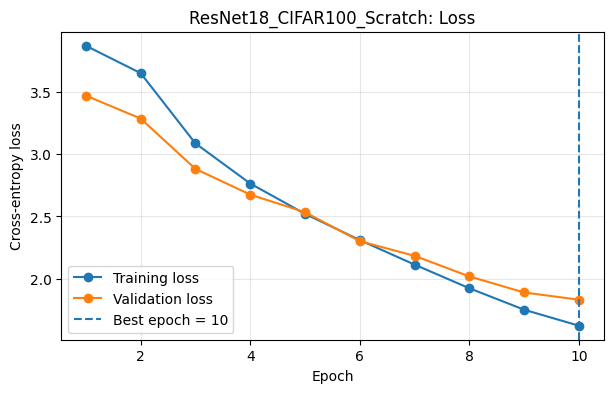

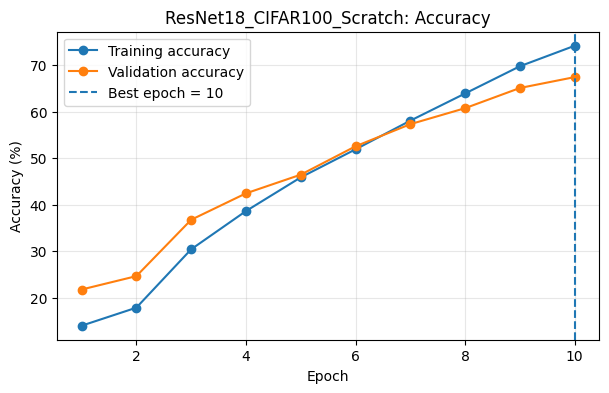

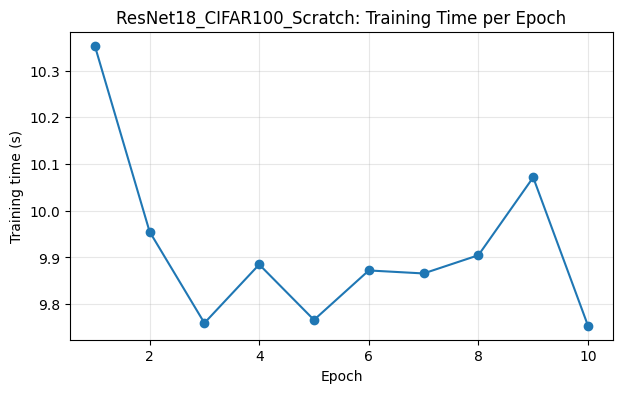

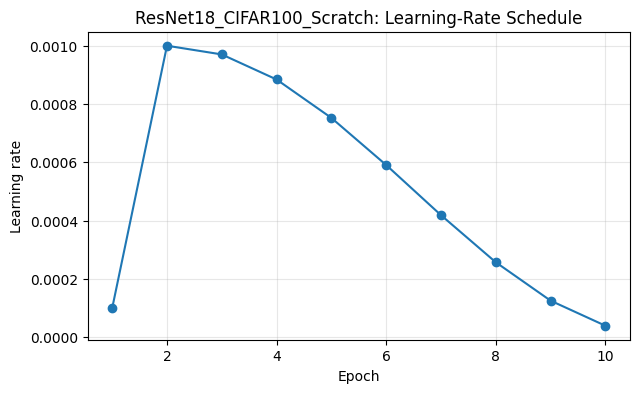

In [ ]:
def build_cifar100_resnet18():
 #ResNet-18 for 32×32 CIFAR-100
    model = resnet18(weights=None)

    model.conv1 = nn.Conv2d(
        3,
        64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )
    model.maxpool = nn.Identity()

    # 100 class head.
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


print("\n" + "=" * 90)
print("Training: ResNet18_CIFAR100_Scratch")
print("=" * 90)

resnet_model = build_cifar100_resnet18().to(device)

resnet_total_params, resnet_trainable_params = count_parameters(resnet_model)
resnet_model_size = calculate_model_size(resnet_model)
resnet_flops = calculate_forward_flops(resnet_model, (3, 32, 32))

resnet_model, resnet_history, resnet_training_summary = train_classifier(
    model=resnet_model,
    train_loader=p1_train_loader,
    val_loader=p1_val_loader,
    epochs=P1_EPOCHS,
    learning_rate=P1_LEARNING_RATE,
    experiment_name="ResNet18_CIFAR100",
    weight_decay=P1_WEIGHT_DECAY,
    gradient_clip_norm=P1_GRADIENT_CLIP_NORM,
    label_smoothing=P1_LABEL_SMOOTHING,
    warmup_epochs=P1_WARMUP_EPOCHS,
    early_stopping_patience=P1_EARLY_STOPPING_PATIENCE,
)

criterion = nn.CrossEntropyLoss(
    label_smoothing=P1_LABEL_SMOOTHING,
)
resnet_test_loss, resnet_test_accuracy = evaluate_classifier(
    resnet_model,
    p1_test_loader,
    criterion,
)

resnet_result = {
    "model": "ResNet18_CIFAR100",
    "model_family": "ResNet-18",
    "patch_size": np.nan,
    "d_model": np.nan,
    "blocks": 18,
    "heads": np.nan,
    "mlp_dim": np.nan,
    "dropout": np.nan,
    "weight_decay": resnet_training_summary["weight_decay"],
    "label_smoothing": resnet_training_summary["label_smoothing"],
    "gradient_clip_norm": resnet_training_summary["gradient_clip_norm"],
    "scheduler": resnet_training_summary["scheduler"],
    "best_epoch": resnet_training_summary["best_epoch"],
    "epochs_trained": resnet_training_summary["epochs_trained"],
    "theoretical_params": np.nan,
    "actual_params": resnet_total_params,
    "trainable_params": resnet_trainable_params,
    "model_size": resnet_model_size,
    "flops_forward_batch1": resnet_flops,
    "total_training_time_s": resnet_training_summary["total_training_time_s"],
    "mean_training_time_per_epoch_s": resnet_training_summary[
        "mean_training_time_per_epoch_s"
    ],
    "best_train_loss": resnet_training_summary["best_train_loss"],
    "best_val_loss": resnet_training_summary["best_val_loss"],
    "best_val_accuracy": resnet_training_summary["best_val_accuracy"],
    "test_loss_best_checkpoint": resnet_test_loss,
    "test_accuracy_best_checkpoint": resnet_test_accuracy,
    "checkpoint_path": resnet_training_summary["checkpoint_path"],
}

plot_training_history(
    resnet_history,
    "ResNet18_CIFAR100_Scratch",
    best_epoch=resnet_training_summary["best_epoch"],
)

,model,model_family,patch_size,d_model,blocks,heads,mlp_dim,dropout,weight_decay,label_smoothing,...,model_size,flops_forward_batch1,total_training_time_s,mean_training_time_per_epoch_s,best_train_loss,best_val_loss,best_val_accuracy,test_loss_best_checkpoint,test_accuracy_best_checkpoint,checkpoint_path
0,ResNet18_CIFAR100_Scratch,ResNet-18,NaN,NaN,18,NaN,NaN,NaN,0.0001,0.1,...,42.838181,1110937600,106.471530,9.918684,1.624125,1.832451,0.6740,1.841326,0.6710,/content/vit_cifar100_outputs/checkpoints/ResN...
1,ViT_P4_D256_L8_H8,Scratch ViT,4.0,256.0,8,8.0,1024.0,0.1,0.0001,0.1,...,24.313858,854124544,223.475248,21.561270,2.905233,2.875132,0.3688,2.871412,0.3707,/content/vit_cifar100_outputs/checkpoints/ViT_...
2,ViT_P4_D256_L4_H4,Scratch ViT,4.0,256.0,4,4.0,1024.0,0.1,0.0001,0.1,...,12.263077,427874304,125.618053,11.838988,3.014339,2.990286,0.3348,2.996587,0.3325,/content/vit_cifar100_outputs/checkpoints/ViT_...
3,ViT_P8_D512_L8_H8,Scratch ViT,8.0,512.0,8,8.0,2048.0,0.1,0.0001,0.1,...,96.814835,863621120,222.382702,21.466995,3.337553,3.343067,0.2598,3.365679,0.2480,/content/vit_cifar100_outputs/checkpoints/ViT_...
4,ViT_P8_D512_L4_H8,Scratch ViT,8.0,512.0,4,8.0,2048.0,0.1,0.0001,0.1,...,48.713272,433434624,124.674946,11.744858,3.338007,3.360975,0.2520,3.378139,0.2449,/content/vit_cifar100_outputs/checkpoints/ViT_...


Saved: /content/vit_cifar100_outputs/problem1_final_comparison_best_checkpoints.csv
Saved: /content/vit_cifar100_outputs/problem1_final_comparison_best_checkpoints.html


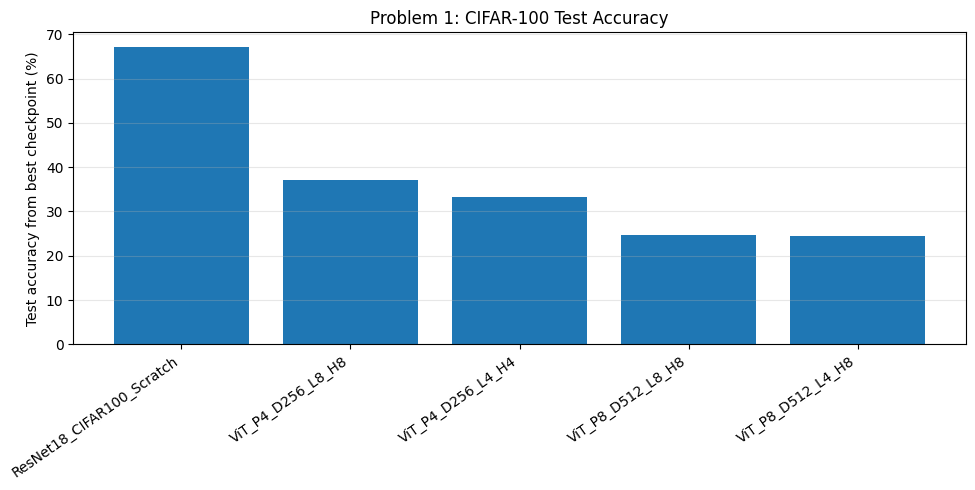

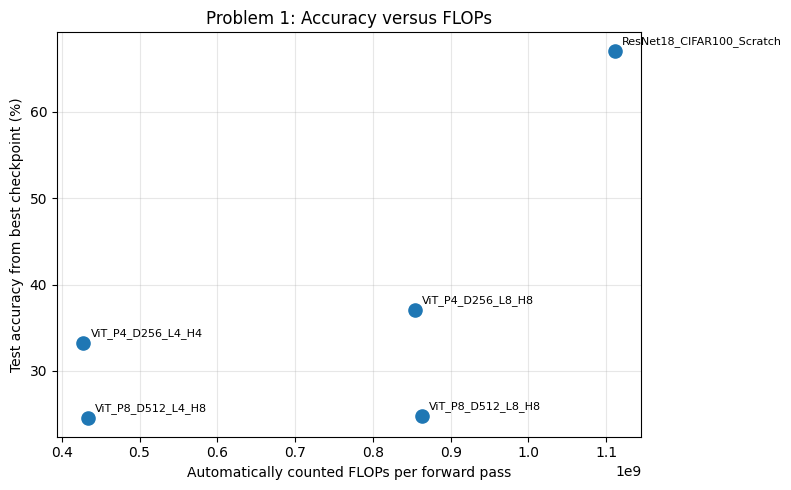

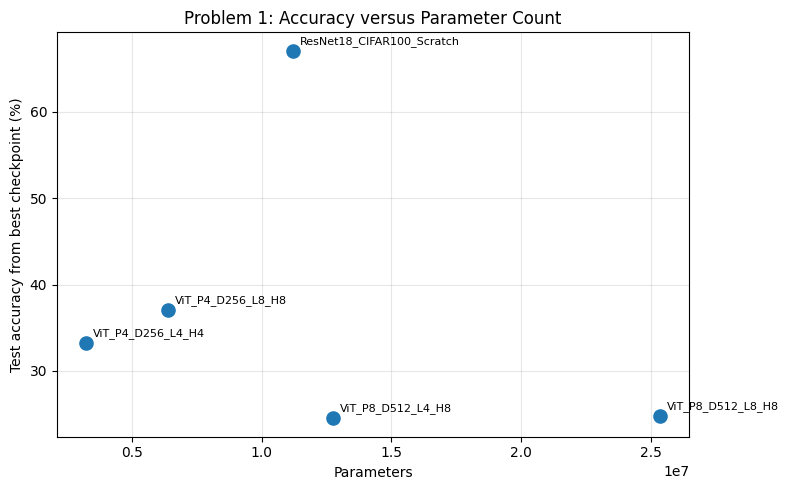

In [ ]:
p1_final_df = pd.concat(
    [p1_vit_results_df, pd.DataFrame([resnet_result])],
    ignore_index=True,
)

p1_final_df = p1_final_df.sort_values(
    "test_accuracy_best_checkpoint",
    ascending=False,
).reset_index(drop=True)

display(p1_final_df)
save_results_table(
    p1_final_df,
    "problem1_final_comparison_best_checkpoints",
)

plt.figure(figsize=(10, 5))
plt.bar(
    p1_final_df["model"],
    p1_final_df["test_accuracy_best_checkpoint"] * 100,
)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Test accuracy from best checkpoint (%)")
plt.title("Problem 1: CIFAR-100 Test Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    p1_final_df["flops_forward_batch1"],
    p1_final_df["test_accuracy_best_checkpoint"] * 100,
    s=90,
)
for _, row in p1_final_df.iterrows():
    plt.annotate(
        row["model"],
        (
            row["flops_forward_batch1"],
            row["test_accuracy_best_checkpoint"] * 100,
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
plt.xlabel("Automatically counted FLOPs per forward pass")
plt.ylabel("Test accuracy from best checkpoint (%)")
plt.title("Problem 1: Accuracy versus FLOPs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    p1_final_df["actual_params"],
    p1_final_df["test_accuracy_best_checkpoint"] * 100,
    s=90,
)
for _, row in p1_final_df.iterrows():
    plt.annotate(
        row["model"],
        (
            row["actual_params"],
            row["test_accuracy_best_checkpoint"] * 100,
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
    )
plt.xlabel("Parameters")
plt.ylabel("Test accuracy from best checkpoint (%)")
plt.title("Problem 1: Accuracy versus Parameter Count")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_p1 = p1_final_df.iloc[0]

print("Best Problem 1 model:", best_p1["model"])
print("Best validation epoch:", int(best_p1["best_epoch"]))
print(
    f"Best validation accuracy: "
    f"{best_p1['best_val_accuracy'] * 100:.2f}%"
)
print(
    f"Test accuracy from restored best checkpoint: "
    f"{best_p1['test_accuracy_best_checkpoint'] * 100:.2f}%"
)
print(f"Parameters: {int(best_p1['actual_params']):,}")
print(f"Model size: {best_p1['model_size']:.2f} MiB")
print(f"Forward FLOPs: {int(best_p1['flops_forward_batch1']):,}")
print(
    f"Mean training time per epoch: "
    f"{best_p1['mean_training_time_per_epoch_s']:.2f} s"
)
print("Checkpoint:", best_p1["checkpoint_path"])

Best Problem 1 model: ResNet18_CIFAR100_Scratch
Best validation epoch: 10
Best validation accuracy: 67.40%
Test accuracy from restored best checkpoint: 67.10%
Parameters: 11,220,132
Model size: 42.84 MiB
Forward FLOPs: 1,110,937,600
Mean training time per epoch: 9.92 s
Checkpoint: /content/vit_cifar100_outputs/checkpoints/ResNet18_CIFAR100_Scratch_best.pt


# Problem 2 — Fine-tuning pretrained Swin Transformers vs. training from Scratch



In [ ]:
P2_BATCH_SIZE = 32 #for 244x244 images
P2_EPOCHS = 5
P2_PRETRAINED_LR = 2e-5
P2_SCRATCH_LR = 1e-3
P2_IMAGE_SIZE = 224

#weight decay only on new head
P2_PRETRAINED_WEIGHT_DECAY = 1e-5
P2_SCRATCH_WEIGHT_DECAY = 1e-4
P2_GRADIENT_CLIP_NORM = 1.0
P2_PRETRAINED_LABEL_SMOOTHING = 0.0 #no smoothing
P2_SCRATCH_LABEL_SMOOTHING = 0.1

P2_PRETRAINED_WARMUP_EPOCHS = 0 #no warmup for pretrained
P2_SCRATCH_WARMUP_EPOCHS = 1 #1 epoch for warmup on Swin


P2_EARLY_STOPPING_PATIENCE = None #no early stopping for the 5 epochs
#identify the pretrained Swin-Tiny checkpoint from Hugging Face
SWIN_TINY_ID = "microsoft/swin-tiny-patch4-window7-224"
SWIN_SMALL_ID = "microsoft/swin-small-patch4-window7-224"

# Read normalization values with the pretrained checkpoint
swin_processor = AutoImageProcessor.from_pretrained(SWIN_TINY_ID)
swin_mean = tuple(swin_processor.image_mean)
swin_std = tuple(swin_processor.image_std)

print("Mean:", swin_mean)
print("Standard deviation:", swin_std)

p2_train_transform = transforms.Compose([
    # data augmentation
    transforms.RandomResizedCrop(
        P2_IMAGE_SIZE,
        scale=(0.8, 1.0),
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(swin_mean, swin_std),
])

p2_eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(P2_IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(swin_mean, swin_std),
])

p2_full_train_aug = datasets.CIFAR100(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=p2_train_transform,
)

p2_full_train_eval = datasets.CIFAR100(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=p2_eval_transform,
)

p2_test_dataset = datasets.CIFAR100(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=p2_eval_transform,
)

p2_train_dataset = Subset(p2_full_train_aug, train_indices)
p2_val_dataset = Subset(p2_full_train_eval, val_indices)

p2_train_loader = DataLoader(
    p2_train_dataset,
    batch_size=P2_BATCH_SIZE,
    shuffle=True,
    **loader_kwargs,
)

p2_val_loader = DataLoader(
    p2_val_dataset,
    batch_size=P2_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

p2_test_loader = DataLoader(
    p2_test_dataset,
    batch_size=P2_BATCH_SIZE,
    shuffle=False,
    **loader_kwargs,
)

print("Train:", len(p2_train_dataset))
print("Validation:", len(p2_val_dataset))
print("Test:", len(p2_test_dataset))

preprocessor_config.json:   0%|          | 0.00/255 [00:00<?, ?B/s]

Mean: (0.485, 0.456, 0.406)
Standard deviation: (0.229, 0.224, 0.225)
Train: 45000
Validation: 5000
Test: 10000


In [ ]:
class HuggingFaceSwinAdapter(nn.Module):
#Hugging Face model adapter
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, images):
        return self.model(pixel_values=images).logits

    def set_eval(self):
        #Keep evaluation mode
        self.model.swin.eval()


def build_pretrained_hf_swin(model_id):
    #Load pretrained Swin
    id2label = {
        index: class_name
        for index, class_name in enumerate(p2_test_dataset.classes)
    }
    label2id = {
        class_name: index
        for index, class_name in id2label.items()
    }

    hf_model = SwinForImageClassification.from_pretrained(
        model_id,
        num_labels=NUM_CLASSES,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    for parameter in hf_model.swin.parameters():
        parameter.requires_grad = False

    for parameter in hf_model.classifier.parameters():
        parameter.requires_grad = True

    return HuggingFaceSwinAdapter(hf_model)


def build_scratch_swin_tiny():
    #Swin-T with random initialization
    return swin_t(weights=None, num_classes=NUM_CLASSES)


Training: Swin-Tiny_Pretrained_HeadOnly


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch 01/5 | lr 2.000e-05 | train loss 4.0934 | train acc 0.2225 | val loss 3.5864 | val acc 0.4452 | time 44.10 s | BEST
Epoch 02/5 | lr 1.811e-05 | train loss 3.1967 | train acc 0.5179 | val loss 2.8633 | val acc 0.5654 | time 44.71 s | BEST
Epoch 03/5 | lr 1.316e-05 | train loss 2.6391 | train acc 0.5868 | val loss 2.4671 | val acc 0.6000 | time 44.44 s | BEST
Epoch 04/5 | lr 7.041e-06 | train loss 2.3557 | train acc 0.6094 | val loss 2.2945 | val acc 0.6116 | time 43.85 s | BEST
Epoch 05/5 | lr 2.091e-06 | train loss 2.2447 | train acc 0.6177 | val loss 2.2479 | val acc 0.6156 | time 44.92 s | BEST
Restored best checkpoint from epoch 5: val acc 0.6156, val loss 2.2479
Saved best checkpoint: /content/vit_cifar100_outputs/checkpoints/Swin-Tiny_Pretrained_HeadOnly_best.pt


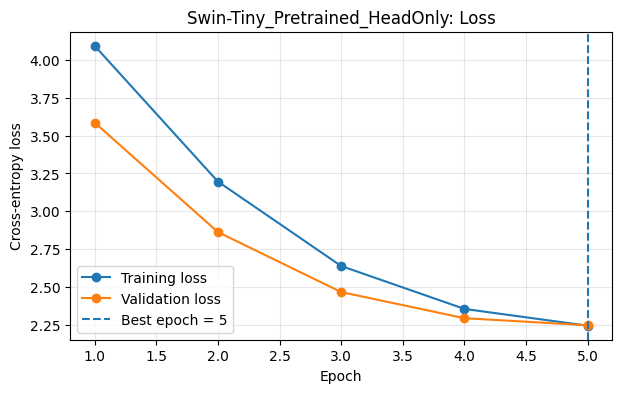

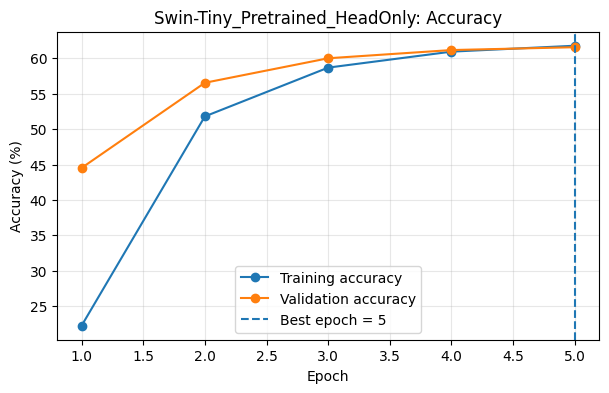

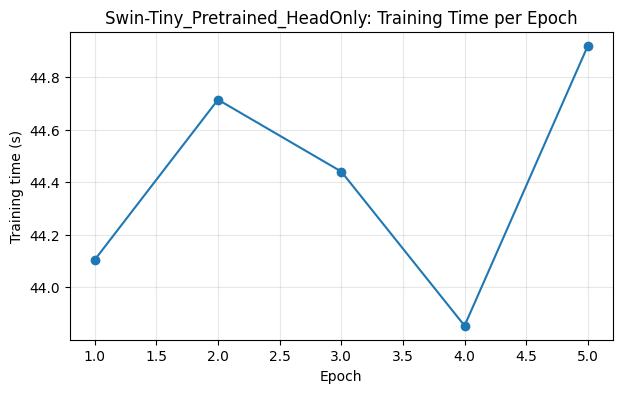

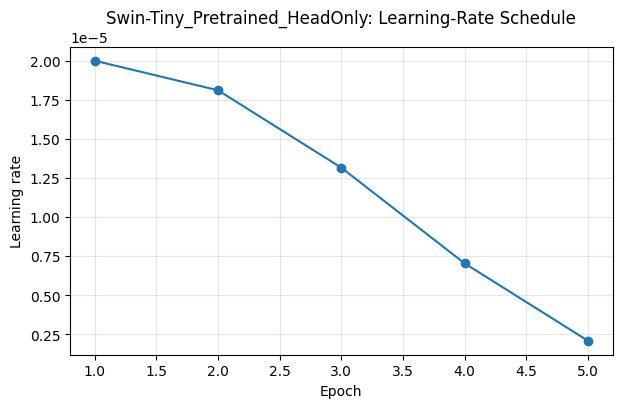


Training: Swin-Small_Pretrained_HeadOnly


config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

[transformers] You passed `num_labels=100` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin:   0%|          | 0.00/199M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/425 [00:00<?, ?it/s]

[transformers] SwinForImageClassification LOAD REPORT from: microsoft/swin-small-patch4-window7-224
Key               | Status   |                                                                                            
------------------+----------+--------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([100])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([100, 768])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/199M [00:00<?, ?B/s]

Epoch 01/5 | lr 2.000e-05 | train loss 4.0628 | train acc 0.2528 | val loss 3.5094 | val acc 0.5030 | time 58.27 s | BEST
Epoch 02/5 | lr 1.811e-05 | train loss 3.0761 | train acc 0.5686 | val loss 2.7150 | val acc 0.6110 | time 59.08 s | BEST
Epoch 03/5 | lr 1.316e-05 | train loss 2.4710 | train acc 0.6259 | val loss 2.2884 | val acc 0.6366 | time 58.06 s | BEST
Epoch 04/5 | lr 7.041e-06 | train loss 2.1717 | train acc 0.6459 | val loss 2.1075 | val acc 0.6472 | time 59.33 s | BEST
Epoch 05/5 | lr 2.091e-06 | train loss 2.0564 | train acc 0.6538 | val loss 2.0590 | val acc 0.6494 | time 59.58 s | BEST
Restored best checkpoint from epoch 5: val acc 0.6494, val loss 2.0590
Saved best checkpoint: /content/vit_cifar100_outputs/checkpoints/Swin-Small_Pretrained_HeadOnly_best.pt


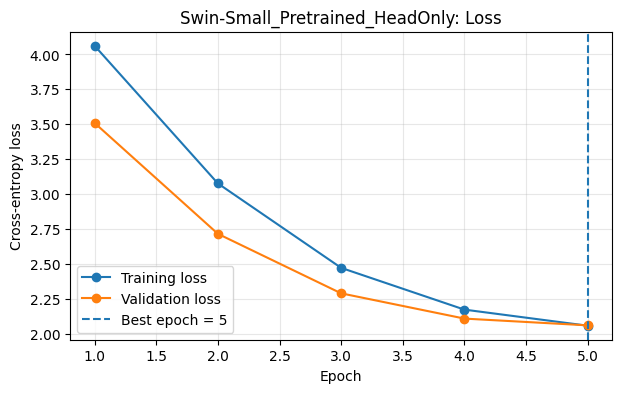

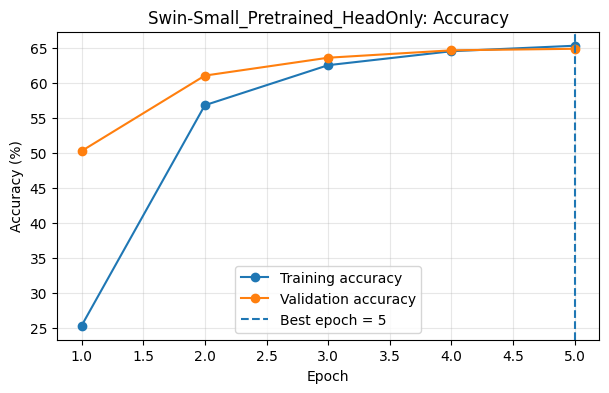

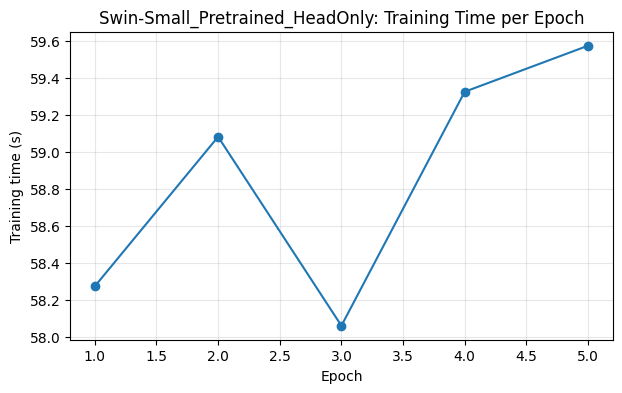

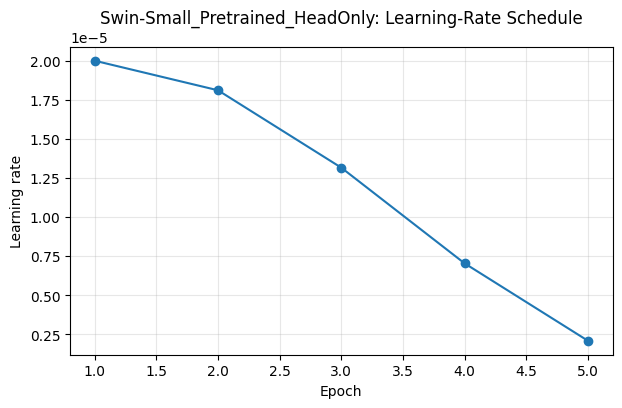


Training: Swin-Tiny_Scratch
Epoch 01/5 | lr 1.000e-04 | train loss 4.1002 | train acc 0.0883 | val loss 3.7701 | val acc 0.1518 | time 94.49 s | BEST
Epoch 02/5 | lr 1.000e-03 | train loss 4.4695 | train acc 0.0333 | val loss 4.4522 | val acc 0.0290 | time 94.43 s
Epoch 03/5 | lr 8.550e-04 | train loss 4.3108 | train acc 0.0572 | val loss 4.1686 | val acc 0.0844 | time 94.51 s
Epoch 04/5 | lr 5.050e-04 | train loss 4.0913 | train acc 0.0964 | val loss 3.9794 | val acc 0.1310 | time 94.30 s
Epoch 05/5 | lr 1.550e-04 | train loss 3.9342 | train acc 0.1272 | val loss 3.8536 | val acc 0.1562 | time 94.81 s | BEST
Restored best checkpoint from epoch 5: val acc 0.1562, val loss 3.8536
Saved best checkpoint: /content/vit_cifar100_outputs/checkpoints/Swin-Tiny_Scratch_best.pt


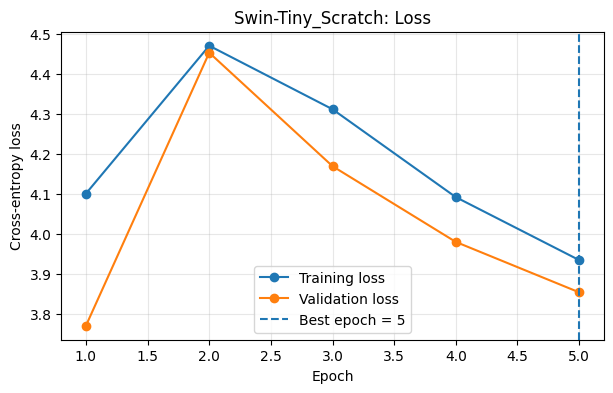

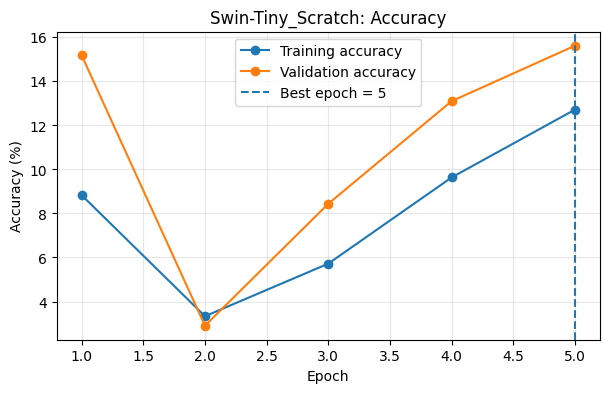

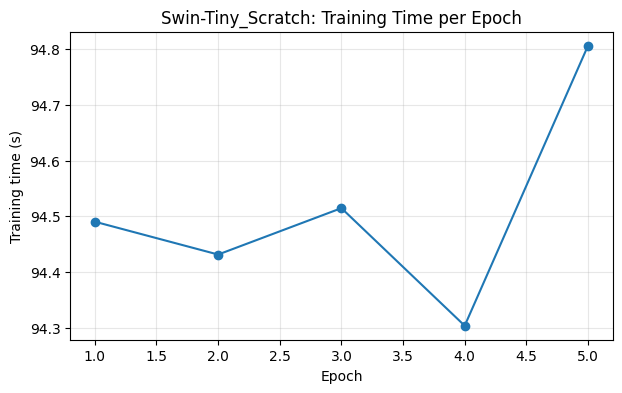

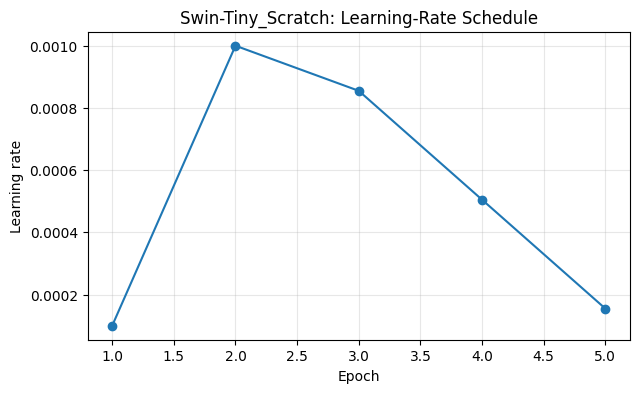

,model,initialization,training_scope,epochs_requested,epochs_trained,best_epoch,batch_size,learning_rate,weight_decay,label_smoothing,...,model_size,flops_forward_batch1,total_training_time_s,mean_training_time_per_epoch_s,best_train_loss,best_val_loss,best_val_accuracy,test_loss_best_checkpoint,test_accuracy_best_checkpoint,checkpoint_path
0,Swin-Small_Pretrained_HeadOnly,ImageNet pretrained,Head only,5,5,5,32,0.00002,0.00001,0.0,...,187.032341,17480368128,327.085970,58.863534,2.056365,2.059011,0.6494,2.082246,0.6529,/content/vit_cifar100_outputs/checkpoints/Swin...
1,Swin-Tiny_Pretrained_HeadOnly,ImageNet pretrained,Head only,5,5,5,32,0.00002,0.00001,0.0,...,105.491173,8979750912,246.594634,44.406884,2.244746,2.247924,0.6156,2.273344,0.6091,/content/vit_cifar100_outputs/checkpoints/Swin...
2,Swin-Tiny_Scratch,Random,Entire model,5,5,5,32,0.00100,0.00010,0.1,...,105.491173,8979750912,496.441162,94.509341,3.934151,3.853569,0.1562,3.864085,0.1459,/content/vit_cifar100_outputs/checkpoints/Swin...


Saved: /content/vit_cifar100_outputs/problem2_swin_comparison_best_checkpoints.csv
Saved: /content/vit_cifar100_outputs/problem2_swin_comparison_best_checkpoints.html


In [ ]:
P2_EXPERIMENTS = [ #Train and evaluate all three Swin models
    {
        "name": "Swin-Tiny_Pretrained_HeadOnly",
        "builder": lambda: build_pretrained_hf_swin(SWIN_TINY_ID),
        "learning_rate": P2_PRETRAINED_LR,
        "weight_decay": P2_PRETRAINED_WEIGHT_DECAY,
        "label_smoothing": P2_PRETRAINED_LABEL_SMOOTHING,
        "warmup_epochs": P2_PRETRAINED_WARMUP_EPOCHS,
        "initialization": "ImageNet pretrained",
        "training_scope": "Head only",
    },
    {
        "name": "Swin-Small_Pretrained_HeadOnly",
        "builder": lambda: build_pretrained_hf_swin(SWIN_SMALL_ID),
        "learning_rate": P2_PRETRAINED_LR,
        "weight_decay": P2_PRETRAINED_WEIGHT_DECAY,
        "label_smoothing": P2_PRETRAINED_LABEL_SMOOTHING,
        "warmup_epochs": P2_PRETRAINED_WARMUP_EPOCHS,
        "initialization": "ImageNet pretrained",
        "training_scope": "Head only",
    },
    {
        "name": "Swin-Tiny_Scratch",
        "builder": build_scratch_swin_tiny,
        "learning_rate": P2_SCRATCH_LR,
        "weight_decay": P2_SCRATCH_WEIGHT_DECAY,
        "label_smoothing": P2_SCRATCH_LABEL_SMOOTHING,
        "warmup_epochs": P2_SCRATCH_WARMUP_EPOCHS,
        "initialization": "Random",
        "training_scope": "Entire model",
    },
]

p2_results = []
p2_histories = {}

for experiment in P2_EXPERIMENTS:
    print("\n" + "=" * 90)
    print("Training:", experiment["name"])
    print("=" * 90)

    model = experiment["builder"]().to(device)

    total_params, trainable_params = count_parameters(model)
    model_size = calculate_model_size(model)
    forward_flops = calculate_forward_flops(
        model,
        (3, P2_IMAGE_SIZE, P2_IMAGE_SIZE),
    )

    # best validation checkpoint.
    model, history, training_summary = train_classifier(
        model=model,
        train_loader=p2_train_loader,
        val_loader=p2_val_loader,
        epochs=P2_EPOCHS,
        learning_rate=experiment["learning_rate"],
        experiment_name=experiment["name"],
        weight_decay=experiment["weight_decay"],
        gradient_clip_norm=P2_GRADIENT_CLIP_NORM,
        label_smoothing=experiment["label_smoothing"],
        warmup_epochs=experiment["warmup_epochs"],
        early_stopping_patience=P2_EARLY_STOPPING_PATIENCE,
    )

    criterion = nn.CrossEntropyLoss(
        label_smoothing=experiment["label_smoothing"],
    )
    test_loss, test_accuracy = evaluate_classifier(
        model,
        p2_test_loader,
        criterion,
    )

    p2_histories[experiment["name"]] = history

    p2_results.append({
        "model": experiment["name"],
        "initialization": experiment["initialization"],
        "training_scope": experiment["training_scope"],
        "epochs_requested": P2_EPOCHS,
        "epochs_trained": training_summary["epochs_trained"],
        "best_epoch": training_summary["best_epoch"],
        "batch_size": P2_BATCH_SIZE,
        "learning_rate": experiment["learning_rate"],
        "weight_decay": training_summary["weight_decay"],
        "label_smoothing": training_summary["label_smoothing"],
        "gradient_clip_norm": training_summary["gradient_clip_norm"],
        "scheduler": training_summary["scheduler"],
        "total_params": total_params,
        "trainable_params": trainable_params,
        "eval_params": total_params - trainable_params,
        "model_size": model_size,
        "flops_forward_batch1": forward_flops,
        "total_training_time_s": training_summary["total_training_time_s"],
        "mean_training_time_per_epoch_s": training_summary[
            "mean_training_time_per_epoch_s"
        ],
        "best_train_loss": training_summary["best_train_loss"],
        "best_val_loss": training_summary["best_val_loss"],
        "best_val_accuracy": training_summary["best_val_accuracy"],
        "test_loss_best_checkpoint": test_loss,
        "test_accuracy_best_checkpoint": test_accuracy,
        "checkpoint_path": training_summary["checkpoint_path"],
    })

    plot_training_history(
        history,
        experiment["name"],
        best_epoch=training_summary["best_epoch"],
    )

    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

p2_results_df = pd.DataFrame(p2_results).sort_values(
    "test_accuracy_best_checkpoint",
    ascending=False,
).reset_index(drop=True)

display(p2_results_df)
save_results_table(
    p2_results_df,
    "problem2_swin_comparison_best_checkpoints",
)

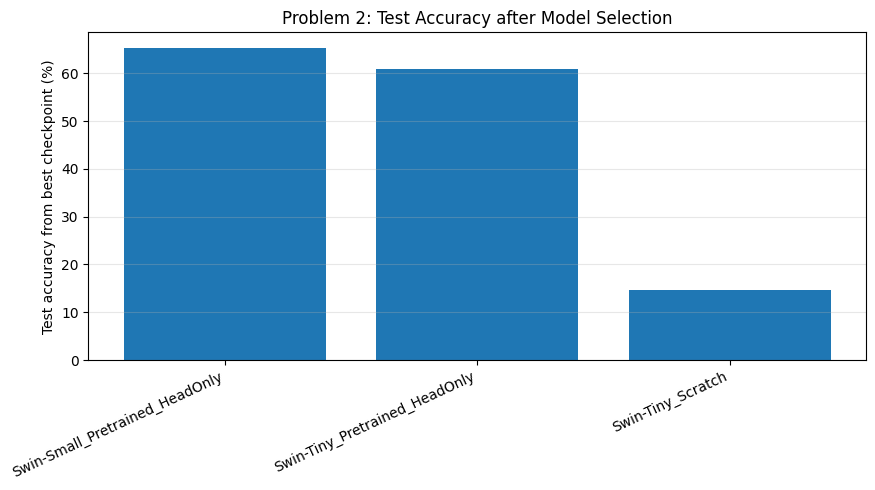

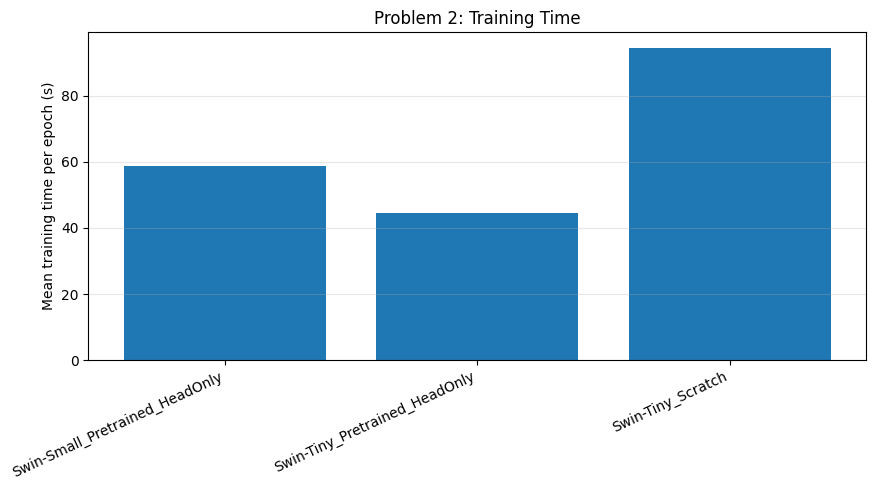

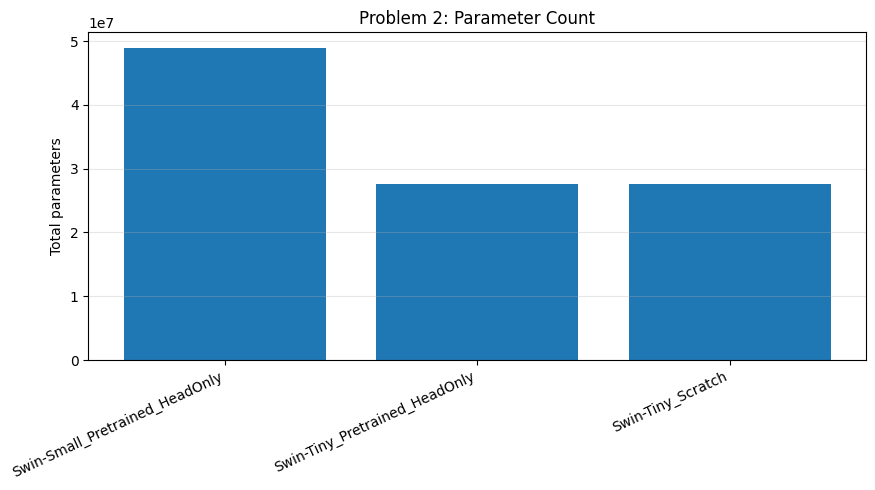

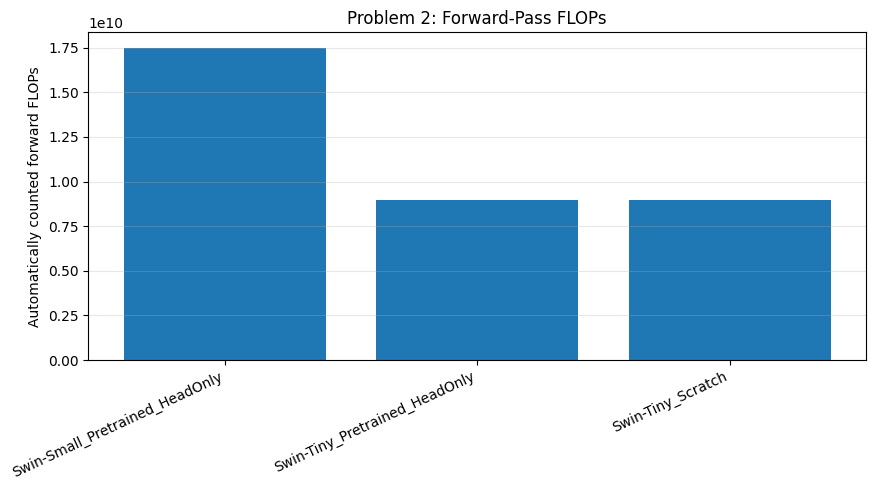

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(
    p2_results_df["model"],
    p2_results_df["test_accuracy_best_checkpoint"] * 100,
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Test accuracy from best checkpoint (%)")
plt.title("Problem 2: Test Accuracy after Model Selection")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(
    p2_results_df["model"],
    p2_results_df["mean_training_time_per_epoch_s"],
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Mean training time per epoch (s)")
plt.title("Problem 2: Training Time")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(
    p2_results_df["model"],
    p2_results_df["total_params"],
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Total parameters")
plt.title("Problem 2: Parameter Count")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(
    p2_results_df["model"],
    p2_results_df["flops_forward_batch1"],
)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Automatically counted forward FLOPs")
plt.title("Problem 2: Forward-Pass FLOPs")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
best_p2 = p2_results_df.iloc[0]

print("Best Problem 2 model:", best_p2["model"])
print("Best validation epoch:", int(best_p2["best_epoch"]))
print(
    f"Best validation accuracy: "
    f"{best_p2['best_val_accuracy'] * 100:.2f}%"
)
print(
    f"Test accuracy from restored best checkpoint: "
    f"{best_p2['test_accuracy_best_checkpoint'] * 100:.2f}%"
)
print(f"Total parameters: {int(best_p2['total_params']):,}")
print(f"Trainable parameters: {int(best_p2['trainable_params']):,}")
print(f"Model size: {best_p2['model_size']:.2f} MiB")
print(f"Forward FLOPs: {int(best_p2['flops_forward_batch1']):,}")
print(
    f"Mean training time per epoch: "
    f"{best_p2['mean_training_time_per_epoch_s']:.2f} s"
)
print("Checkpoint:", best_p2["checkpoint_path"])

Best Problem 2 model: Swin-Small_Pretrained_HeadOnly
Best validation epoch: 5
Best validation accuracy: 64.94%
Test accuracy from restored best checkpoint: 65.29%
Total parameters: 48,914,158
Trainable parameters: 76,900
Model size: 187.03 MiB
Forward FLOPs: 17,480,368,128
Mean training time per epoch: 58.86 s
Checkpoint: /content/vit_cifar100_outputs/checkpoints/Swin-Small_Pretrained_HeadOnly_best.pt


In [ ]:
p1_summary = p1_final_df[[
    "model",
    "model_family",
    "best_epoch",
    "actual_params",
    "trainable_params",
    "model_size",
    "flops_forward_batch1",
    "mean_training_time_per_epoch_s",
    "best_val_accuracy",
    "test_accuracy_best_checkpoint",
]].copy()

p1_summary.insert(0, "problem", "Problem 1")
p1_summary = p1_summary.rename(
    columns={"actual_params": "total_params"}
)

p2_summary = p2_results_df[[
    "model",
    "initialization",
    "best_epoch",
    "total_params",
    "trainable_params",
    "model_size",
    "flops_forward_batch1",
    "mean_training_time_per_epoch_s",
    "best_val_accuracy",
    "test_accuracy_best_checkpoint",
]].copy()

p2_summary.insert(0, "problem", "Problem 2")
p2_summary = p2_summary.rename(
    columns={"initialization": "model_family"}
)

final_results_df = pd.concat(
    [p1_summary, p2_summary],
    ignore_index=True,
)

display(final_results_df)
save_results_table(
    final_results_df,
    "final_all_models_best_checkpoint_summary",
)

,problem,model,model_family,best_epoch,total_params,trainable_params,model_size,flops_forward_batch1,mean_training_time_per_epoch_s,best_val_accuracy,test_accuracy_best_checkpoint
0,Problem 1,ResNet18_CIFAR100_Scratch,ResNet-18,10,11220132,11220132,42.838181,1110937600,9.918684,0.6740,0.6710
1,Problem 1,ViT_P4_D256_L8_H8,Scratch ViT,10,6373732,6373732,24.313858,854124544,21.561270,0.3688,0.3707
2,Problem 1,ViT_P4_D256_L4_H4,Scratch ViT,10,3214692,3214692,12.263077,427874304,11.838988,0.3348,0.3325
3,Problem 1,ViT_P8_D512_L8_H8,Scratch ViT,10,25379428,25379428,96.814835,863621120,21.466995,0.2598,0.2480
4,Problem 1,ViT_P8_D512_L4_H8,Scratch ViT,10,12769892,12769892,48.713272,433434624,11.744858,0.2520,0.2449
5,Problem 2,Swin-Small_Pretrained_HeadOnly,ImageNet pretrained,5,48914158,76900,187.032341,17480368128,58.863534,0.6494,0.6529
6,Problem 2,Swin-Tiny_Pretrained_HeadOnly,ImageNet pretrained,5,27596254,76900,105.491173,8979750912,44.406884,0.6156,0.6091
7,Problem 2,Swin-Tiny_Scratch,Random,5,27596254,27596254,105.491173,8979750912,94.509341,0.1562,0.1459


Saved: /content/vit_cifar100_outputs/final_all_models_best_checkpoint_summary.csv
Saved: /content/vit_cifar100_outputs/final_all_models_best_checkpoint_summary.html


# References
 official PyTorch CIFAR-100, ResNet-18, Swin, and FLOP-counter APIs and the Hugging Face Swin image-classification API.